In [8]:
import pandas as pd
import matplotlib.pyplot as plt
# using the same cleaned data from the earlier notebooks so everything stays consistent
master = pd.read_csv('../data/processed/master_cleaned.csv')

timestamp_cols = ['order_purchase_timestamp', 'order_approved_at', 
                   'order_delivered_timestamp', 'order_estimated_delivery_date']
for col in timestamp_cols:
    master[col] = pd.to_datetime(master[col])

# only orders that were actually delivered (with a real delivery date) can be
# labeled late or on-time, so everything else gets dropped for this model
model_df = master[
    (master['order_status'] == 'delivered') &
    (master['order_delivered_timestamp'].notnull())
].copy()

# target: 1 if delivered after the estimated date, 0 if on time or early
# same definition used for the on-time/late split in 03_sales_analysis.sql
model_df['is_late'] = (
    model_df['order_delivered_timestamp'] > model_df['order_estimated_delivery_date']
).astype(int)

print('Modeling dataset shape:', model_df.shape)
print()
print('Target distribution:')
print(model_df['is_late'].value_counts())
print(model_df['is_late'].value_counts(normalize=True).round(3))

Modeling dataset shape: (87422, 24)

Target distribution:
is_late
0    80685
1     6737
Name: count, dtype: int64
is_late
0    0.923
1    0.077
Name: proportion, dtype: float64


In [2]:
# picking features that would actually be known at the time of purchase —
# nothing that leaks future info like the delivery timestamp itself.
# using price, shipping, payment info, category, and state since those
# are the fields we already explored in EDA/SQL and know are populated
# cleanly with no major issues.

model_df['purchase_month'] = model_df['order_purchase_timestamp'].dt.month
model_df['purchase_dayofweek'] = model_df['order_purchase_timestamp'].dt.dayofweek

feature_cols = ['price', 'shipping_charges', 'payment_type', 'payment_installments',
                 'payment_value', 'product_category_name', 'customer_state',
                 'purchase_month', 'purchase_dayofweek']

X = model_df[feature_cols]
y = model_df['is_late']

print(X.dtypes)
print()
print(X.isnull().sum())

price                    float64
shipping_charges         float64
payment_type                 str
payment_installments       int64
payment_value            float64
product_category_name        str
customer_state               str
purchase_month             int32
purchase_dayofweek         int32
dtype: object

price                    0
shipping_charges         0
payment_type             0
payment_installments     0
payment_value            0
product_category_name    0
customer_state           0
purchase_month           0
purchase_dayofweek       0
dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

# splitting before encoding so there's no chance of test data leaking
# into how categories get encoded. using stratify on y since the target
# is imbalanced (7.7% late) — this keeps the same late/on-time ratio
# in both the train and test sets instead of risking an uneven split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# one-hot encoding the categorical columns — turns each category into
# its own 0/1 column since models need numbers, not text labels
X_train_encoded = pd.get_dummies(X_train, columns=['payment_type', 'product_category_name', 'customer_state'])
X_test_encoded = pd.get_dummies(X_test, columns=['payment_type', 'product_category_name', 'customer_state'])

# train and test might not end up with the exact same category columns
# (e.g. a rare category only appears in one split), so aligning them
# here to make sure both have identical columns in the same order
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print('Train shape:', X_train_encoded.shape)
print('Test shape:', X_test_encoded.shape)
print('Train late rate:', y_train.mean().round(3))
print('Test late rate:', y_test.mean().round(3))

Train shape: (69937, 108)
Test shape: (17485, 108)
Train late rate: 0.077
Test late rate: 0.077


In [5]:
from sklearn.preprocessing import StandardScaler

# logistic regression is sensitive to feature scale, and our numeric
# features (price, payment_value, etc.) are on very different scales.
# scaling fixes the convergence warning and usually helps the model
# perform better too, not just train cleaner
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print()
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.69      0.80     16138
           1       0.12      0.51      0.20      1347

    accuracy                           0.68     17485
   macro avg       0.53      0.60      0.50     17485
weighted avg       0.88      0.68      0.75     17485


Confusion matrix:
[[11121  5017]
 [  657   690]]


In [6]:
from sklearn.ensemble import RandomForestClassifier

# logistic regression assumes roughly linear relationships between
# features and the outcome, but our correlation check earlier showed
# very weak linear relationships across the board. trying random forest
# instead since it can pick up on non-linear patterns and feature
# interactions that logistic regression would miss entirely
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', 
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_encoded, y_train)  # tree models don't need scaled features

y_pred_rf = rf_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred_rf))
print()
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.76      0.84     16138
           1       0.15      0.52      0.23      1347

    accuracy                           0.74     17485
   macro avg       0.55      0.64      0.54     17485
weighted avg       0.89      0.74      0.80     17485


Confusion matrix:
[[12226  3912]
 [  653   694]]


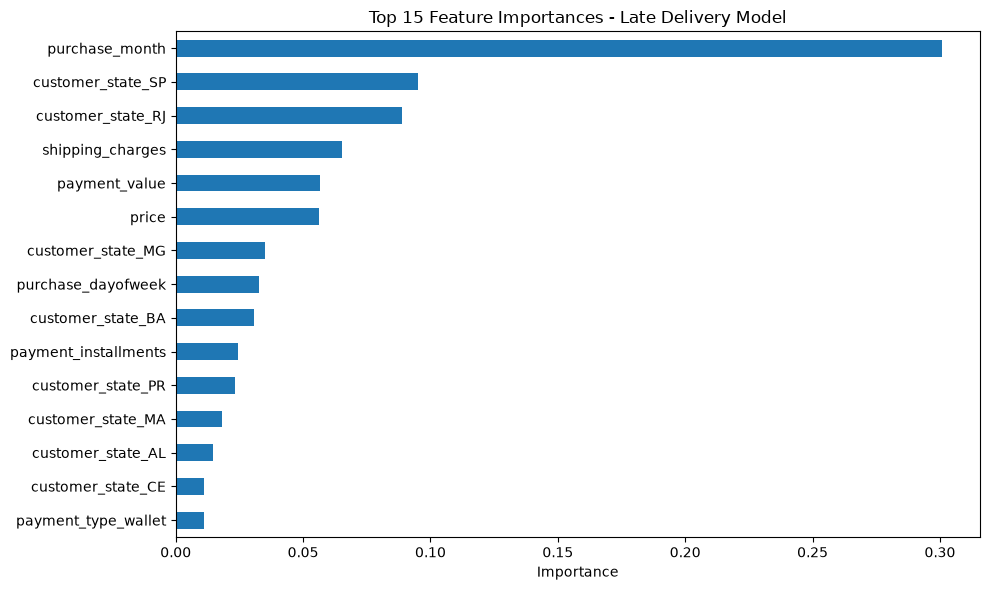

purchase_month          0.300691
customer_state_SP       0.095273
customer_state_RJ       0.088868
shipping_charges        0.065453
payment_value           0.056770
price                   0.056404
customer_state_MG       0.034919
purchase_dayofweek      0.032614
customer_state_BA       0.030751
payment_installments    0.024639
customer_state_PR       0.023256
customer_state_MA       0.018145
customer_state_AL       0.014711
customer_state_CE       0.011185
payment_type_wallet     0.011139
dtype: float64


In [9]:
# even though the model isn't highly accurate, checking which features
# it's relying on most is still useful — tells us what (weakly) relates
# to late delivery, which is a legitimate finding on its own
importances = pd.Series(rf_model.feature_importances_, index=X_train_encoded.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title('Top 15 Feature Importances - Late Delivery Model')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_features)